In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('clasification.csv')

In [3]:
df = df.iloc[:,1:]

In [4]:
df

,petal_length,sepal_length,species
0,1.4,5.1,setosa
1,1.4,4.9,setosa
2,1.3,4.7,setosa
3,1.5,4.6,setosa
4,1.4,5.0,setosa
...,...,...,...
95,4.2,5.7,versicolor
96,4.2,5.7,versicolor
97,4.3,6.2,versicolor
98,3.0,5.1,versicolor


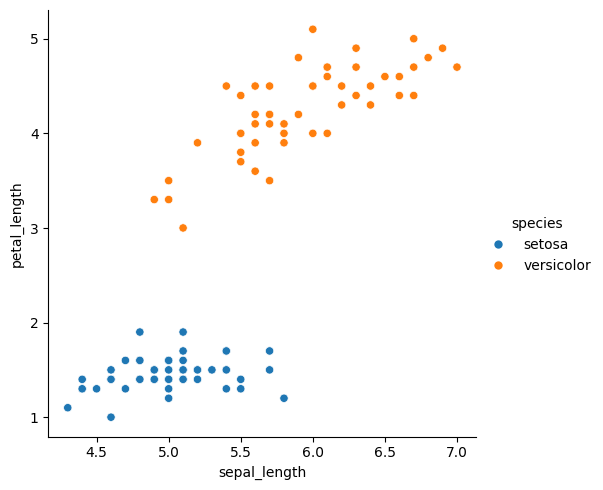

In [5]:
sns.relplot(data = df, y='petal_length',x = 'sepal_length',kind = 'scatter',hue = 'species')
# sns.relplot(data = df, x=i, y=j, kind = 'scatter', hue = 'species')

In [6]:
df['species'] = df['species'].map({
    'setosa': 1,
    'versicolor': -1
})

In [10]:
df.sample(5)

,petal_length,sepal_length,species
93,3.3,5.0,-1
65,4.4,6.7,-1
55,4.5,5.7,-1
4,1.4,5.0,1
33,1.4,5.5,1


In [214]:
# class SVM:
#     def __init__(self, lr_rate = 0.001, epoch =1000, C = 1):
#         self.lr = lr_rate
#         self.epoch = epoch
#         self.coef_ = None
#         self.intercept_ = 0
#         self.C = C

#     def fit(self,x,y):
#         col = x.shape[1]
#         row = x.shape[0]

#          x = x.to_numpy() 
#         y = y.to_numpy()

#         self.coef_ = np.zeros(col)

#         for j in range(self.epoch):
#             for i in range(row):
#                 xi = x[i]
#                 yi = y[i]
#                 condition = (yi*(np.dot(xi,self.coef_)) + self.intercept_) >= 1
#                 if condition:
#                     self.coef_-= self.lr*self.coef_
#                 else :
#                     self.coef_ -= self.lr *(self.coef_ - self.C * yi * xi)
#                     self.intercept_ += self.lr* self.C * yi
#     def pred(self,x):
#         return np.dot(self.coef_, x.T) + self.intercept_
class SVM:
    def __init__(self, lr_rate=0.001, epoch=1000, C=1):
        self.lr = lr_rate
        self.epoch = epoch
        self.coef_ = None
        self.intercept_ = 0
        self.C = C

    def fit(self, x, y):
        # Convert to numpy for safety
        x = x.to_numpy() 
        y = y.to_numpy()

        row, col = x.shape
        self.coef_ = np.zeros(col)

        for _ in range(self.epoch):
            for i in range(row):
                xi, yi = x[i], y[i]
                condition = yi * (np.dot(xi, self.coef_) + self.intercept_) >= 1

                if condition:
                    # Gradient of ‖w‖²/2 = w
                    self.coef_ -= self.lr * self.coef_
                else:
                    # Gradient of ‖w‖²/2 - C*y*x
                    self.coef_ -= self.lr * (self.coef_ - self.C * yi * xi)
                    self.intercept_ += self.lr * self.C * yi

    def pred(self, x):
        x = x.to_numpy() if hasattr(x, 'to_numpy') else x
        return np.sign(np.dot(x, self.coef_) + self.intercept_)

In [159]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1],train_size=0.8, random_state=42)

In [222]:
model = SVM()
model.fit(x_train, y_train)

In [223]:
model.coef_

array([-0.64570769, -0.13206967])

In [224]:
model.intercept_

np.float64(2.5119999999998344)

In [225]:
pred = model.pred(df.iloc[:,:-1])
pred 

array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1.])

In [228]:
from sklearn.metrics import confusion_matrix
confusion_matrix(pred,y_test)

ValueError: Found input variables with inconsistent numbers of samples: [100, 20, 100]

In [109]:
import numpy as np
import matplotlib.pyplot as plt

X = df.iloc[:,:-1]

y = df.iloc[:,-1]

# initialize
w = np.zeros(X.shape[1])
b = 0

lr = 0.001
epochs = 1000
C = 1

# training loop
for _ in range(epochs):
    for i in range(len(X)):
        condition = y[i] * (np.dot(w, X.iloc[i]) + b) >= 1

        if condition:
            w -= lr * (2 * w)
        else:
            w -= lr * (2 * w - C * y[i] * X.iloc[i])
            b -= lr * (-C * y[i])

print("w:", w)
print("b:", b)

w: petal_length   -0.422680
sepal_length   -0.200895
Name: 0, dtype: float64
b: 1.767999999999916


In [150]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [160]:
mod = SVC(C=1, kernel='linear')
mod.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [161]:
mod.coef_

array([[-1.32206475, -0.23060477]])

In [219]:
mod.intercept_
pre = mod.predict(x_test)

In [227]:
from sklearn.metrics import confusion_matrix
confusion_matrix(pre,y_test)

array([[ 8,  0],
       [ 0, 12]])

In [168]:
pred

array([0.7355601 , 0.74310686, 0.75436773, 0.75071288, 0.73933348,
       0.71309762, 0.75442699, 0.73561936, 0.76197375, 0.73939274,
       0.72052585, 0.739452  , 0.74688024, 0.77688947, 0.71657469,
       0.70920572, 0.72795409, 0.7355601 , 0.70177749, 0.73184599,
       0.71309762, 0.73184599, 0.76928346, 0.72441775, 0.72830966,
       0.73190525, 0.73190525, 0.72807261, 0.73178673, 0.74322538,
       0.739452  , 0.72052585, 0.72807261, 0.72046659, 0.73939274,
       0.74676171, 0.72418071, 0.74310686, 0.76568786, 0.73184599,
       0.7430476 , 0.76191449, 0.76568786, 0.73190525, 0.71698952,
       0.74688024, 0.72813187, 0.75442699, 0.72429923, 0.73933348,
       0.54130009, 0.57136859, 0.53764524, 0.62389957, 0.5638811 ,
       0.59778223, 0.56771374, 0.67253865, 0.56010772, 0.63893382,
       0.66133704, 0.60137783, 0.60503268, 0.57526049, 0.63498266,
       0.56376257, 0.60155561, 0.60886532, 0.57891535, 0.62384031,
       0.57909313, 0.6012593 , 0.5602855 , 0.57526049, 0.57879

In [169]:
pre

array([-1, -1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,
       -1,  1,  1])